In [29]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from testCases_v2 import *
from public_tests import *
import sklearn
import sklearn.datasets
import sklearn.linear_model
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
from planar_utils import load_planar_dataset

In [31]:
X, Y = load_planar_dataset()

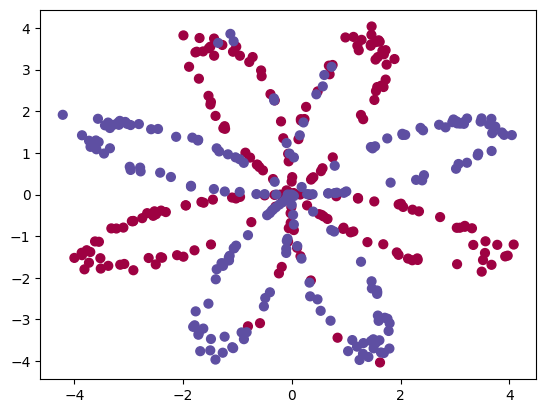

In [32]:
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral)

In [33]:
print(f"Shape of X = {X.shape}")
print(f"Shape of Y = {Y.shape}")
m = X.shape[1]
print(f"Number of training examples : {m}")
print(X[:, :5], Y[:, :5])

Shape of X = (2, 400)
Shape of Y = (1, 400)
Number of training examples : 400
[[ 1.20444229  0.1587099   0.0952472   0.34917847  0.69415038]
 [ 3.57611415 -1.4821709  -1.27995533 -2.06437997  2.88910878]] [[0 0 0 0 0]]


In [34]:
# Train the logistic regression classifier
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T, Y.ravel())

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


In [35]:
def plot_decision_boundary(model, X, y):
    xmin, xmax = min(X[0, :]) - 1, max(X[0, :]) + 1
    ymin, ymax = min(X[1, :]) - 1, max(X[1, :] + 1)
    h = 0.001

    xx, yy = np.meshgrid(np.arange(xmin, xmax, h), np.arange(ymin, ymax, h))
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel("X2")
    plt.xlabel("X1")
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)

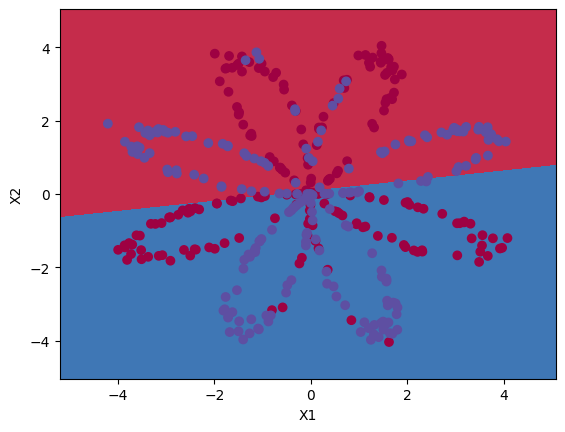

In [36]:
model = lambda x: clf.predict(x)
plot_decision_boundary(model, X, Y)

In [37]:
LR_predictions = model(X.T)
errors = LR_predictions == Y.ravel()
accuracy = errors.mean() * 100
print(
    f"Accuracy of logistic regression: {accuracy} % (percentage of correctly labelled datapoints)"
)
# errors = np.abs(LR_predictions.astype(int) - Y.ravel().astype(int))
# accuracy = 100 - errors.mean() * 100
# print(accuracy)

Accuracy of logistic regression: 47.0 % (percentage of correctly labelled datapoints)


In [38]:
n_x = X.shape[0]
n_h = 4
n_y = Y.shape[0]
print(f"The size of the input layer is: n_x = {n_x}")
print(f"The size of the hidden layer is: n_h = {n_h}")
print(f"The size of the output layer is: n_y = {n_y}")

The size of the input layer is: n_x = 2
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 1


In [39]:
def initialize_parameters(n_x, n_h, n_y):
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters

In [40]:
np.random.seed(2)
n_x, n_h, n_y = initialize_parameters_test_case()
parameters = initialize_parameters(n_x, n_h, n_y)

print(f"W1 = {parameters["W1"]}")
print(f"b1 = {parameters["b1"]}")
print(f"W2 = {parameters["W2"]}")
print(f"b2 = {parameters["b2"]}")

initialize_parameters_test(initialize_parameters)

W1 = [[-0.00416758 -0.00056267]
 [-0.02136196  0.01640271]
 [-0.01793436 -0.00841747]
 [ 0.00502881 -0.01245288]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.01057952 -0.00909008  0.00551454  0.02292208]]
b2 = [[0.]]
All tests passed!


In [41]:
def sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

In [42]:
def forward_propagation(X, param):
    W1, b1, W2, b2 = param["W1"], param["b1"], param["W2"], param["b2"]
    Z1 = W1 @ X + b1
    A1 = np.tanh(Z1)
    # A1 = np.maximum(0, Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    cache = {"Z1": Z1, "Z2": Z2, "A1": A1, "A2": A2}
    return A2, cache

In [43]:
t_X, parameters = forward_propagation_test_case()
A2, cache = forward_propagation(t_X, parameters)
print(f"A2 = {A2}")
forward_propagation_test(forward_propagation)

A2 = [[0.21292656 0.21274673 0.21295976]]
All tests passed!


In [44]:
def compute_cost(A2, Y):
    # m = Y.shape[1]
    # cost = np.dot(Y, (np.log(A2)).T) + np.dot((1 - Y), (np.log(1 - A2).T))
    # cost = -cost / m
    # A2, Y = A2.ravel(), Y.ravel()
    # m = Y.shape[0]
    # cost = np.dot(Y, np.log(A2)) + np.dot((1 - Y), np.log(1 - A2))
    # cost = -cost / m
    # cost = float(np.squeeze(cost))
    m = Y.shape[1]
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), (1 - Y))
    cost = -np.sum(logprobs) / m
    cost = float(np.squeeze(cost))
    return cost

In [45]:
A2, t_Y = compute_cost_test_case()
cost = compute_cost(A2, t_Y)
print("cost = " + str(compute_cost(A2, t_Y)))

compute_cost_test(compute_cost)

cost = 0.6930587610394646
All tests passed!


In [46]:
def backward_propagation(param, cache, X, Y):
    W1, W2 = param["W1"], param["W2"]
    A1, A2 = cache["A1"], cache["A2"]
    m = X.shape[1]
    dZ2 = A2 - Y
    dW2 = dZ2 @ A1.T / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m
    dZ1 = (W2.T @ dZ2) * (1 - (A1**2))
    # dZ1 = (W2.T @ dZ2) * np.where(A1 > 0, 1, 0)
    dW1 = dZ1 @ X.T / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m
    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

In [47]:
parameters, cache, t_X, t_Y = backward_propagation_test_case()

grads = backward_propagation(parameters, cache, t_X, t_Y)
print("dW1 = " + str(grads["dW1"]))
print("db1 = " + str(grads["db1"]))
print("dW2 = " + str(grads["dW2"]))
print("db2 = " + str(grads["db2"]))

backward_propagation_test(backward_propagation)

dW1 = [[ 0.00301023 -0.00747267]
 [ 0.00257968 -0.00641288]
 [-0.00156892  0.003893  ]
 [-0.00652037  0.01618243]]
db1 = [[ 0.00176201]
 [ 0.00150995]
 [-0.00091736]
 [-0.00381422]]
dW2 = [[ 0.00078841  0.01765429 -0.00084166 -0.01022527]]
db2 = [[-0.16655712]]
All tests passed!


In [48]:
def update_parameters(params, grads, learning_rate=1.2):
    W1, b1 = copy.deepcopy(params["W1"]), params["b1"]
    W2, b2 = copy.deepcopy(params["W2"]), params["b2"]
    dW1, db1 = copy.deepcopy(grads["dW1"]), grads["db1"]
    dW2, db2 = copy.deepcopy(grads["dW2"]), grads["db2"]
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters

In [49]:
parameters, grads = update_parameters_test_case()
parameters = update_parameters(parameters, grads)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

update_parameters_test(update_parameters)

W1 = [[-0.00643025  0.01936718]
 [-0.02410458  0.03978052]
 [-0.01653973 -0.02096177]
 [ 0.01046864 -0.05990141]]
b1 = [[-1.02420756e-06]
 [ 1.27373948e-05]
 [ 8.32996807e-07]
 [-3.20136836e-06]]
W2 = [[-0.01041081 -0.04463285  0.01758031  0.04747113]]
b2 = [[0.00010457]]
All tests passed!


In [50]:
def nn_model(X, Y, n_h, num_iterations=10000, print_cost=False):
    np.random.seed(3)
    n_x = X.shape[0]
    n_y = Y.shape[0]
    params = initialize_parameters(n_x, n_h, n_y)
    for i in range(num_iterations):
        A2, cache = forward_propagation(X, params)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(params, cache, X, Y)
        params = update_parameters(params, grads)
        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost}")
    return params

In [51]:
nn_model_test(nn_model)

Cost after iteration 0: 0.693496823649522
Cost after iteration 1000: 0.00018014484912279397
Cost after iteration 2000: 8.831899857567864e-05
Cost after iteration 3000: 5.8371430998042974e-05
Cost after iteration 4000: 4.3552121775568246e-05
Cost after iteration 5000: 3.471783816166423e-05
Cost after iteration 6000: 2.8855066826132143e-05
Cost after iteration 7000: 2.4681755325173633e-05
Cost after iteration 8000: 2.156028585890777e-05
Cost after iteration 9000: 1.913788280145284e-05
W1 = [[-0.48394893 -0.91443482]
 [-0.69227123 -1.28596651]
 [ 0.63806018  1.18124948]
 [ 0.73594679  1.35718308]
 [-0.62621054 -1.16022636]]
b1 = [[ 0.00285386]
 [ 0.01642488]
 [-0.01114986]
 [-0.01656405]
 [ 0.01042274]]
W2 = [[-1.45325879 -2.65768451  2.26286606  2.97274518 -2.18860534]]
b2 = [[0.00758617]]
All tests passed!


In [52]:
def predict(parameters, X):
    A2, cache = forward_propagation(X, parameters)
    return np.where(A2 > 0.5, 1, 0)

In [53]:
parameters, t_X = predict_test_case()
predictions = predict(parameters, t_X)
print(f"Predictions: {predictions}")
predict_test(predict)

Predictions: [[1 0 1]]
All tests passed!


Cost after iteration 0: 0.6931621661402946
Cost after iteration 1000: 0.2586250682869045
Cost after iteration 2000: 0.23933351654583135
Cost after iteration 3000: 0.23080163442975746
Cost after iteration 4000: 0.2255280270817635
Cost after iteration 5000: 0.221844675950227
Cost after iteration 6000: 0.21909438354878744
Cost after iteration 7000: 0.22060781059508414
Cost after iteration 8000: 0.21940999249695575
Cost after iteration 9000: 0.21852563583612258


Text(0.5, 1.0, 'Decision Boundary for hidden layer size 4')

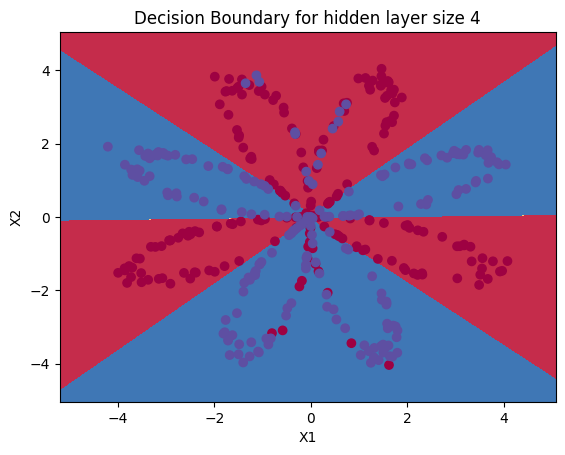

In [54]:
parameters = nn_model(X, Y, n_h=4, num_iterations=10000, print_cost=True)

model = lambda x: predict(parameters, x.T)
plot_decision_boundary(model, X, Y)
plt.title(f"Decision Boundary for hidden layer size 4")

In [55]:
predictions = predict(parameters, X)
accuracy = 100 * np.mean(Y == predictions)
print(accuracy)

90.5


Accuracy for 1 hidden units: 67.5.
Accuracy for 2 hidden units: 67.25.
Accuracy for 3 hidden units: 90.75.
Accuracy for 4 hidden units: 90.5.
Accuracy for 5 hidden units: 91.25.


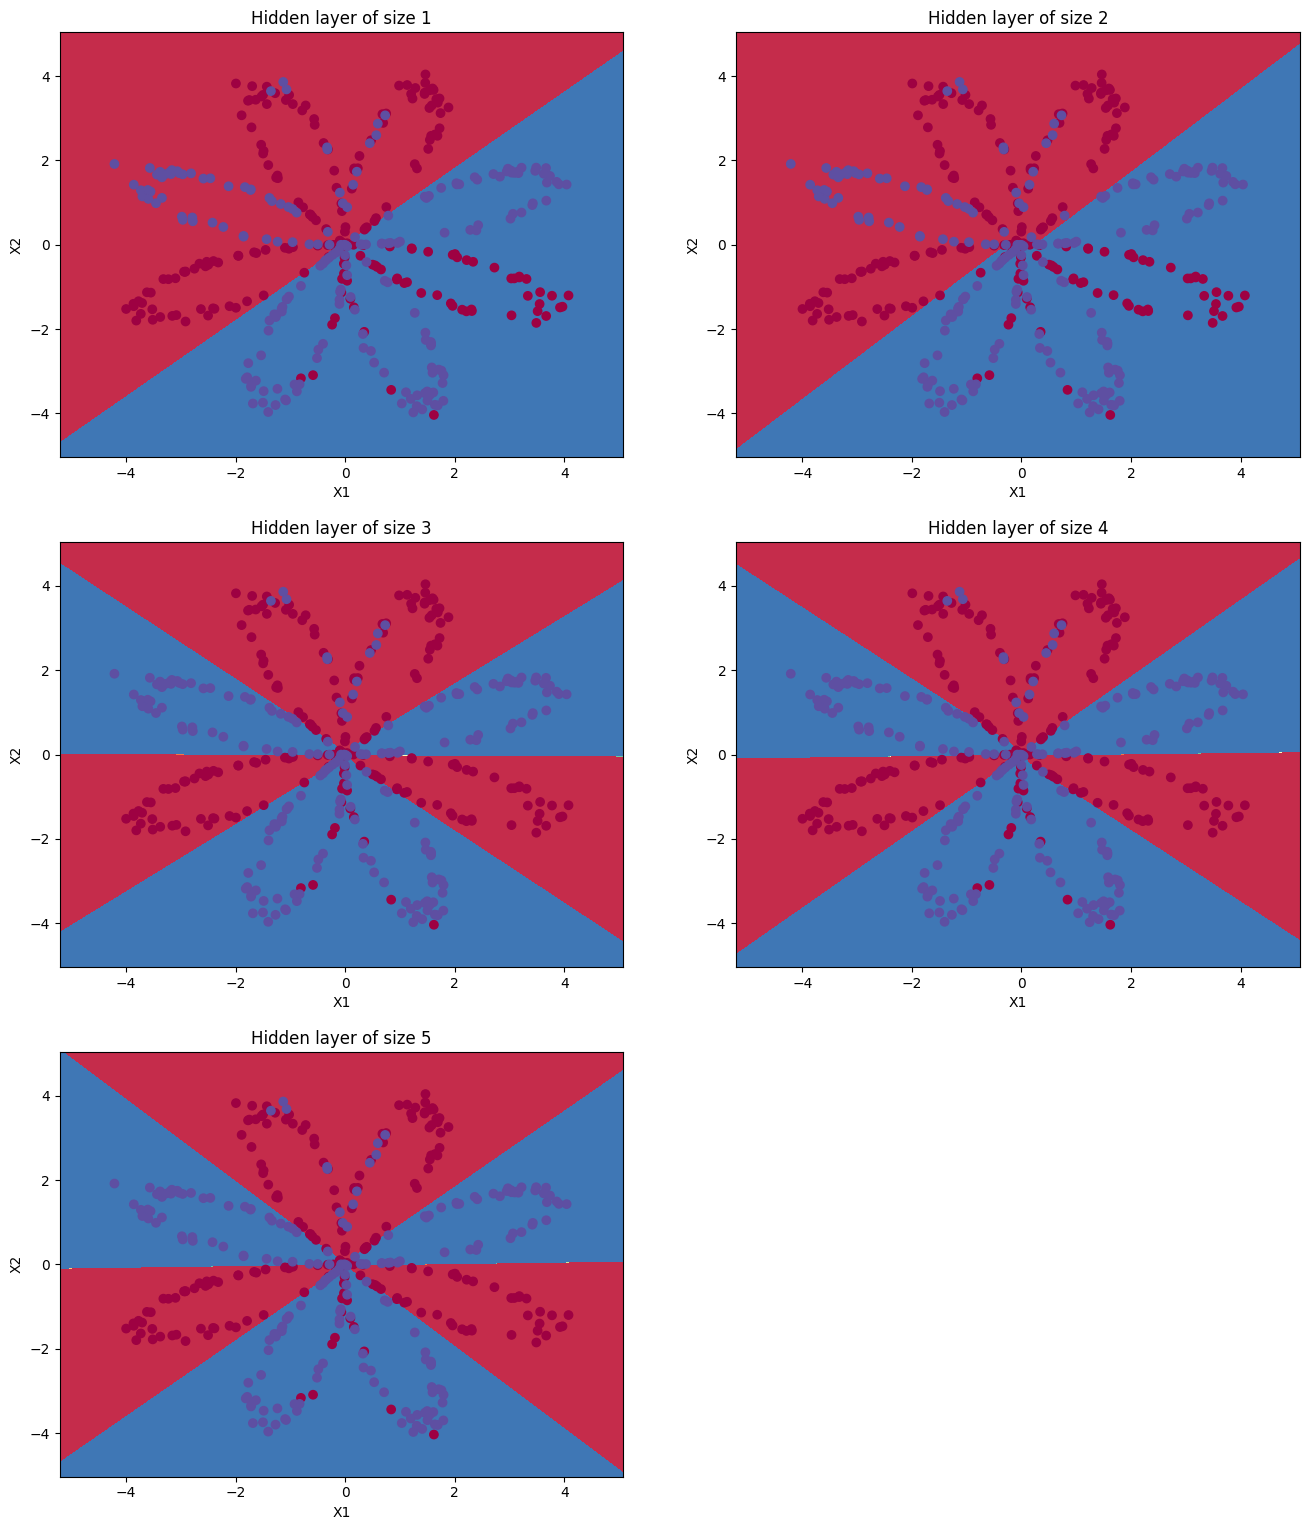

In [56]:
plt.figure(figsize=(16, 32))
hidden_layer_sizes = [1, 2, 3, 4, 5]

for i, n_h in enumerate(hidden_layer_sizes):
    plt.subplot(5, 2, i + 1)
    plt.title(f"Hidden layer of size {n_h}")
    parameters = nn_model(X, Y, n_h, num_iterations=5000)
    plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
    predictions = predict(parameters, X)
    accuracy = 100 * np.mean(Y == predictions)
    print(f"Accuracy for {n_h} hidden units: {accuracy}.")